# Projection in StyleGAN2

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

from dataclasses import dataclass
import pickle

import sys
from pathlib import Path

import cv2
import pandas as pd

PROJECT_DIR = Path.cwd().resolve()
STYLEGAN2_DIR = PROJECT_DIR / 'stylegan2'
if str(STYLEGAN2_DIR) not in sys.path:
    sys.path.insert(0, str(STYLEGAN2_DIR))

from stylegan2 import *
from stylegan2.torch_utils.misc import get_device
import stylegan2.torch_utils.custom_ops as custom_ops

c:\Users\conta\Documents\Dev\Python\IMA\Latent-Space-Faces\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def imshow(images, gray=False):
    n = len(images)
    plt.figure(figsize=(12,5))
    plt.subplot(1, n, 1)
    for i in range(n):
        plt.subplot(1, n, i + 1)
        if gray: plt.imshow(images[i], cmap='gray')
        else: plt.imshow(images[i])
        plt.axis("off")
    plt.show()

In [3]:
def imsave(images, latents, folder):
    num = 0
    data = []
    for i in range(len(images)):
        path = f"{folder}/{num}.png"
        cv2.imwrite(path, images[i])
        data.append({"path":path, "latent":latents[i]})
        num+=1
    np.savez(f"{folder}/data.npz", np.array(data))

In [4]:
SEED = 42
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

OUT_DIR = Path('out')

custom_ops.force_disable_problematic_cuda_kernels = True
device = get_device()
print(device)
print(torch.cuda.is_available())
print(torch.version.cuda)

cuda
True
13.0


In [5]:
def prediction_to_img(pred: torch.Tensor) -> np.ndarray:
    if pred.shape[0] > 1:
        img = pred.permute(0, 2, 3, 1)
        np_img = img.cpu().numpy()

        mini = np_img.min(axis=(1, 2), keepdims=True)
        maxi = np_img.max(axis=(1, 2), keepdims=True)
        np_img = (np_img - mini) / (maxi - mini)
        
        return np_img
    else:
        img = pred[0].permute(1, 2, 0)
        np_img = img.cpu().numpy()

        mini = np_img.min(axis=(0, 1), keepdims=True)
        maxi = np_img.max(axis=(0, 1), keepdims=True)
        np_img = (np_img - mini) / (maxi - mini)

        return np_img

In [6]:
with open('models/stylegan2-ffhq-512x512.pkl', 'rb') as f:
    G = pickle.load(f)['G_ema'].to(device)
    print(G.z_dim)

    for param in G.parameters():
        param.requires_grad = False


512


## VGG

In [7]:
import torch.nn as nn

In [8]:
weights = torchvision.models.VGG16_Weights.IMAGENET1K_FEATURES
feature_model = torchvision.models.vgg16(weights=weights, progress=True).features.to(device)
feature_model.eval()
for param in feature_model.parameters():
    param.requires_grad = False

vgg_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
vgg_std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

def normalize_for_vgg(img: torch.Tensor) -> torch.Tensor:
    img = (img + 1.0) / 2.0
    img = torch.clip(img, 0.0, 1.0)
    return (img - vgg_mean) / vgg_std

## Image Alignement

In [9]:
from download_ffhq import recreate_aligned_images
import dlib
import os

In [10]:
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor('models/shape_predictor_68_face_landmarks.dat')

def extract_face_landmarks(img_path):
    img = dlib.load_rgb_image(img_path)
    dets = detector(img, 1)
    if len(dets) == 0:
        raise ValueError(f"No face detected in image {img_path}")
    shape = predictor(img, dets[0])
    landmarks = [[p.x, p.y] for p in shape.parts()]
    return landmarks

def align_faces(input_dir, output_dir):
    landmarks_list = {}
    for filename in os.listdir(input_dir):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(input_dir, filename)
            try:
                landmarks = extract_face_landmarks(img_path)
                landmarks_list[filename] = {
                    "in_the_wild": {
                        "file_path": filename,
                        "face_landmarks": landmarks
                    }
                }
                print(f"Extracted landmarks from {filename}")
            except Exception as e:
                print(f"Error processing {filename}: {e}")
    print(landmarks_list)
    recreate_aligned_images(landmarks_list, input_dir, output_dir)

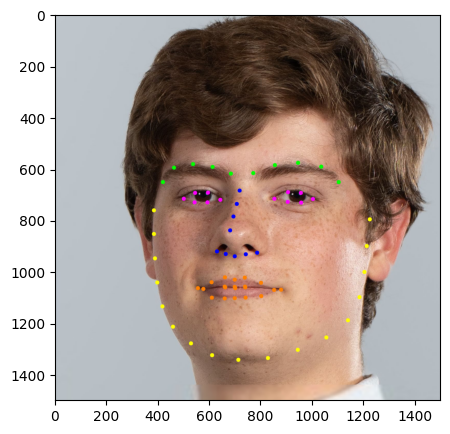

In [11]:
landmarks = extract_face_landmarks('./images_to_align/antonin2.png')

img = cv2.imread('./images_to_align/antonin2.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

zones = {
    'mâchoire':        (range(0, 17),  (255, 255, 0)),
    'sourcil gauche':  (range(17, 22), (0, 255, 0)),
    'sourcil droit':   (range(22, 27), (0, 255, 0)),
    'nez':             (range(27, 36), (0, 0, 255)),
    'oeil gauche':     (range(36, 42), (255, 0, 255)),
    'oeil droit':      (range(42, 48), (255, 0, 255)),
    'bouche':          (range(48, 68), (255, 128, 0)),
}

for zone, (indices, color) in zones.items():
    for i in indices:
        x, y = landmarks[i]
        cv2.circle(img, (x, y), 8, color, -1)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.show()

In [12]:
align_faces('./images_to_align', './images_aligned')

Extracted landmarks from antonin2.png
{'antonin2.png': {'in_the_wild': {'file_path': 'antonin2.png', 'face_landmarks': [[384, 760], [384, 852], [388, 947], [397, 1041], [417, 1134], [458, 1213], [528, 1278], [610, 1324], [712, 1342], [827, 1335], [943, 1303], [1054, 1255], [1138, 1188], [1183, 1098], [1202, 1000], [1211, 899], [1223, 795], [419, 650], [462, 594], [536, 580], [612, 591], [683, 617], [770, 615], [854, 584], [944, 575], [1034, 590], [1102, 650], [717, 683], [706, 735], [693, 784], [680, 838], [629, 920], [663, 930], [698, 939], [741, 931], [785, 925], [500, 715], [544, 692], [594, 691], [642, 719], [592, 729], [542, 729], [852, 715], [905, 689], [955, 692], [1002, 716], [956, 730], [904, 727], [555, 1063], [608, 1040], [660, 1021], [698, 1030], [737, 1022], [800, 1042], [878, 1069], [801, 1094], [740, 1100], [698, 1102], [659, 1103], [609, 1100], [576, 1066], [661, 1060], [700, 1063], [739, 1060], [851, 1070], [738, 1057], [698, 1058], [659, 1057]]}}}
Recreating aligned i

## LPIPS loss

In [13]:
from lpips import LPIPS

In [14]:
lpips_loss = LPIPS(net='vgg').to(device)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


c:\Users\conta\Documents\Dev\Python\IMA\Latent-Space-Faces\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\conta\Documents\Dev\Python\IMA\Latent-Space-Faces\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\conta\Documents\Dev\Python\IMA\Latent-Space-Faces\venv\Lib\site-packages\lpips\weights\v0.1\vgg.pth


## Project in $\mathcal{Z}$

In [15]:
target_img = cv2.imread("./out/seed0001.png")
target_img = cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB)
target = torch.from_numpy(target_img).permute(2, 0, 1)[torch.newaxis, :].float().to(device)
target = (target / 127.5) - 1.0
target = torchvision.transforms.functional.resize(target, (512, 512))
target_features = feature_model(normalize_for_vgg(torchvision.transforms.functional.resize(target, (224, 224))))

criterion = nn.MSELoss()
latent = torch.zeros([1, G.z_dim], device=device)
min_loss = torch.tensor(float('inf'))
w_samples = torch.tensor([]).to(device)
w_avg = torch.tensor(0).to(device)
w_std = torch.tensor(0).to(device)
for i in tqdm(range(1500)):
    latent_temp = torch.randn([1, G.z_dim], device=device)
    w_out = G.mapping(latent_temp, None)
    w_samples = torch.cat((w_samples, w_out), dim=0)
    pred = G.synthesis(w_out, noise_mode='const')
    pred_features = feature_model(normalize_for_vgg(torchvision.transforms.functional.resize(pred, (224, 224))))
    loss = 0.5 * criterion(pred_features, target_features) + 4 * criterion(pred, target)
    if loss < min_loss:
        min_loss = loss
        latent = latent_temp
param = nn.Parameter(latent)
optimizer = torch.optim.Adam(params=[param], lr=1e-4)
w_avg = w_samples.mean(dim=0, keepdim=True)
w_std = w_samples.std(dim=0, keepdim=True)

min_loss = torch.tensor(float('inf'))
res = None
n_iters = 10000
noise_std = 0.1
for it in tqdm(range(n_iters)):
    t = it / n_iters
    noise_scale = w_std * 0.05 * max(0.0, 1.0 - t / 0.75) ** 2

    lr_ramp = min(1.0, (1.0 - t) / 0.25)
    lr_ramp = 0.5 - 0.5 * np.cos(lr_ramp * np.pi)
    lr_ramp = lr_ramp * min(1.0, t / 0.05)
    lr = 0.1 * lr_ramp
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    w_out = G.mapping(param, None)
    w_noise = torch.randn_like(w_out) * noise_scale
    w = (w_out + w_noise)
    pred = G.synthesis(w, noise_mode='const')
    pred_features = feature_model(normalize_for_vgg(torchvision.transforms.functional.resize(pred, (224, 224))))

    loss = 0.5 * criterion(pred_features, target_features) + 4 * criterion(pred, target)
    if loss < min_loss:
        min_loss = loss
        res = param.clone().detach()
    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

    if it % 100 == 0:
        print(f"loss: {min_loss.item():.4f}")

print(f"final loss: {min_loss.item():.4f}")

  1%|          | 11/1500 [00:01<03:05,  8.03it/s]


KeyboardInterrupt: 

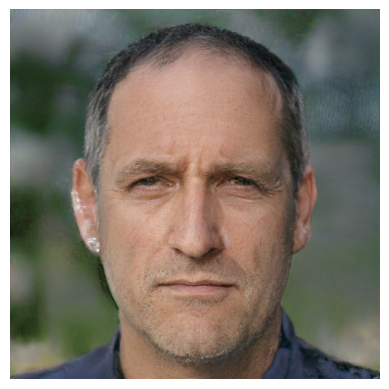

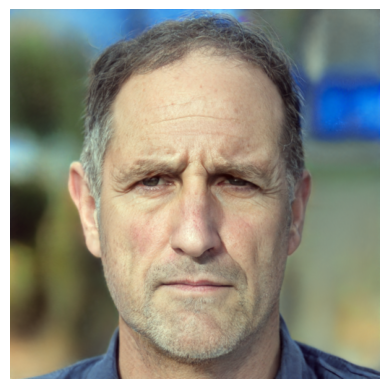

In [ ]:
w = G.mapping(res, None)
pred = G.synthesis(w, noise_mode='const')
im = prediction_to_img(pred.detach())
plt.imshow(im)
plt.axis('off')
plt.show()
im = prediction_to_img(target)
plt.imshow(im)
plt.axis('off')
plt.show()

## Project in $\mathcal{W}$

In [16]:
def noise_reg_loss(noise_buffers):
    loss = torch.tensor(0.0, device=device)
    for buf in noise_buffers.values():
        loss += torch.mean(buf * torch.roll(buf, shifts=1, dims=0)) ** 2
        loss += torch.mean(buf * torch.roll(buf, shifts=1, dims=1)) ** 2
    return loss

In [33]:
target_img = cv2.imread("./images_aligned/antonin2.png")
target_img = cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB)
target = torch.from_numpy(target_img).permute(2, 0, 1)[torch.newaxis, :].float().to(device)
target = (target / 127.5) - 1.0
target = torchvision.transforms.functional.resize(target, (512, 512))
target_features = feature_model(normalize_for_vgg(torchvision.transforms.functional.resize(target, (224, 224))))
    
criterion = nn.MSELoss()
w_opt = torch.zeros([1, G.z_dim], device=device)
min_loss = torch.tensor(float('inf'))
w_samples = torch.tensor([]).to(device)
w_avg = torch.tensor(0).to(device)
w_std = torch.tensor(0).to(device)
for i in tqdm(range(1500)):
    z = torch.randn([1, G.z_dim], device=device)
    w_out = G.mapping(z, None)[:, :1, :]
    w_samples = torch.cat((w_samples, w_out), dim=0)
    pred = G.synthesis(w_out.repeat([1, G.mapping.num_ws, 1]),  noise_mode='const')
    #pred_features = feature_model(normalize_for_vgg(torchvision.transforms.functional.resize(pred, (224, 224))))
    #print(pred_features[0].shape, target_features[0].shape)
    loss =  1 * lpips_loss(pred, target) 
    loss += 0 * criterion(pred, target)
    if loss < min_loss:
        min_loss = loss
        w_opt = w_out[:, :1, :]
w_avg = w_samples.mean(dim=0, keepdim=True)
w_std = w_samples.std(dim=0, keepdim=True)
param = nn.Parameter(w_avg)

min_loss = torch.tensor(float('inf'))
res = None
noise_std = 0.1

losses = []
feature_losses = []
pixel_losses = []
noise_losses = []

noise_bufs = { name: buf for (name, buf) in G.synthesis.named_buffers() if 'noise_const' in name }
best_noise_bufs = { name: buf.clone().detach() for (name, buf) in noise_bufs.items() }
for buf in noise_bufs.values():
    buf.requires_grad = False
    buf[:] = torch.randn_like(buf)
    buf.requires_grad = True
        
optimizer = torch.optim.Adam(params=[param] + list(noise_bufs.values()))

n_iters = 1100
for it in tqdm(range(n_iters)):
    t = it / n_iters
    noise_scale = w_std * 0.05 * max(0.0, 1.0 - t / 0.75) ** 2

    lr_ramp = min(1.0, (1.0 - t) / 0.25)
    lr_ramp = 0.5 - 0.5 * np.cos(lr_ramp * np.pi)
    lr_ramp = lr_ramp * min(1.0, t / 0.05)
    lr = 0.1 * lr_ramp
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    w_noise = torch.randn_like(param) * noise_scale
    w = (param + w_noise).repeat([1, G.mapping.num_ws, 1])
    pred = G.synthesis(w, noise_mode='const')
    #pred_features = feature_model(normalize_for_vgg(torchvision.transforms.functional.resize(pred, (224, 224))))

    feature_loss = 1 * lpips_loss(pred, target)
    pixel_loss = 0 * criterion(pred, target)
    noise_loss = 2e4 * noise_reg_loss(noise_bufs)
    loss = feature_loss + pixel_loss + noise_loss

    if loss < min_loss:
        min_loss = loss
        res = param.clone().detach()
        best_noise_bufs = { name: buf.clone().detach() for (name, buf) in noise_bufs.items() }

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        for buf in noise_bufs.values():
            buf -= torch.mean(buf)
            buf /= (buf.std() + 1e-10)

    losses.append(loss.item())
    noise_losses.append(noise_loss.item())
    feature_losses.append(feature_loss.item())
    pixel_losses.append(pixel_loss.item())

    if it % 100 == 0:
        print(f"loss: {min_loss.item():.4f}")
        print(f"feature_loss: {feature_loss.item():.4f}")
        print(f"pixel_loss: {pixel_loss.item():.4f}")
        print(f"noise_loss: {noise_loss.item():.4f}")

print(f"final loss: {min_loss.item():.4f}")
for name, buf in noise_bufs.items():
    buf.requires_grad = False
    buf.data.copy_(best_noise_bufs[name])

  0%|          | 1/1100 [00:00<05:49,  3.14it/s]

loss: 3658.9116
feature_loss: 0.5877
pixel_loss: 0.0000
noise_loss: 3658.3240


  9%|▉         | 101/1100 [00:32<05:26,  3.06it/s]

loss: 0.6340
feature_loss: 0.2817
pixel_loss: 0.0000
noise_loss: 0.4226


 18%|█▊        | 201/1100 [01:06<04:50,  3.10it/s]

...

loss: 0.2028
feature_loss: 0.2008
pixel_loss: 0.0000
noise_loss: 0.0021


 91%|█████████ | 1001/1100 [05:33<00:31,  3.14it/s]

loss: 0.1927
feature_loss: 0.1927
pixel_loss: 0.0000
noise_loss: 0.0000


100%|██████████| 1100/1100 [05:59<00:00,  3.06it/s]

final loss: 0.1916


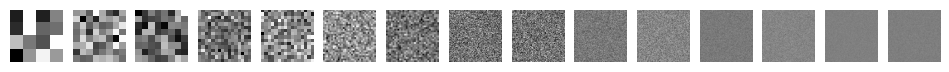

In [48]:
noises = []
for name, buf in noise_bufs.items():
    cpu_buff = buf.detach().cpu().numpy()
    cpu_buff[:] = np.random.randn(*buf.shape)
    buf = cpu_buff
    noises.append(cpu_buff)
imshow(noises, gray=True)

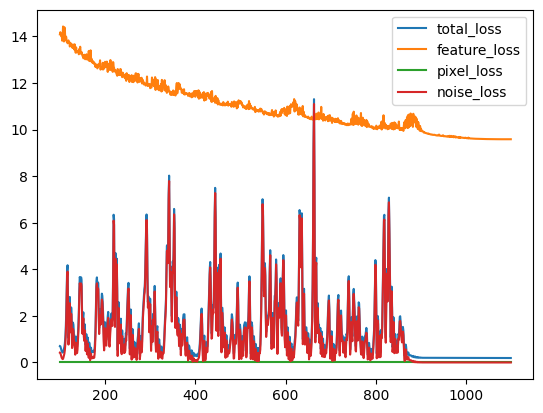

In [49]:
i = np.arange(100, len(losses))
plt.plot(i, np.array(losses)[i], label='total_loss')
plt.plot(i, np.array(feature_losses)[i] * 50, label='feature_loss')
plt.plot(i, np.array(pixel_losses)[i] * 50, label='pixel_loss')
plt.plot(i, np.array(noise_losses)[i], label='noise_loss')
plt.legend()
plt.show()

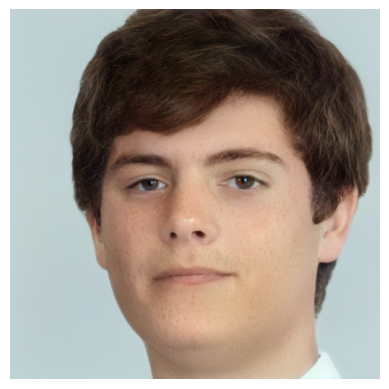

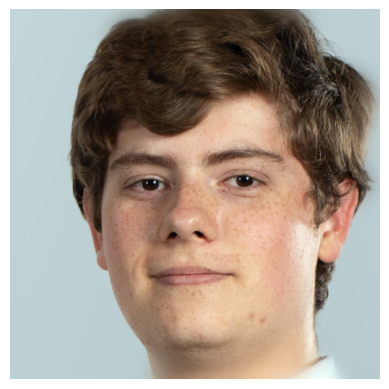

In [50]:
#w = G.mapping(res, None)
pred = G.synthesis(res.repeat([1, G.mapping.num_ws, 1]), noise_mode='const')
im = prediction_to_img(pred.detach())
plt.imshow(im)
plt.axis('off')
plt.show()
im = prediction_to_img(target)
plt.imshow(im)
plt.axis('off')
plt.show()